Load Dataset and Basic EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/HR_comma_sep.csv")  
print(df.head())
print(df.info())
print(df.isnull().sum())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

Understand Target Variable (Retention)

attrition
0    11428
1     3571
Name: count, dtype: int64


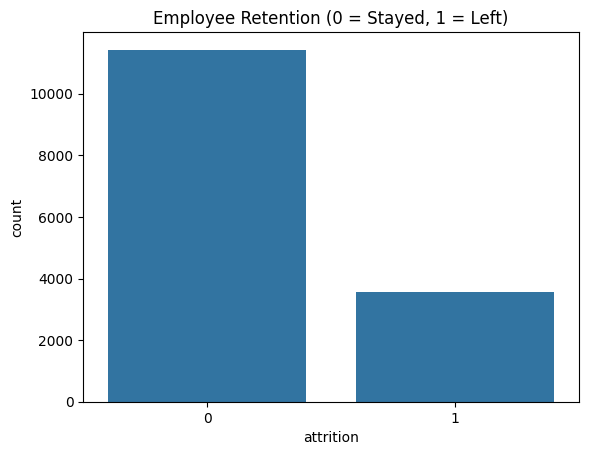

In [ ]:
df.rename(columns={"left": "attrition"}, inplace=True)
print(df["attrition"].value_counts())
sns.countplot(x="attrition", data=df)
plt.title("Employee Retention (0 = Stayed, 1 = Left)")
plt.show()

Key Insight Variables (EDA selection)

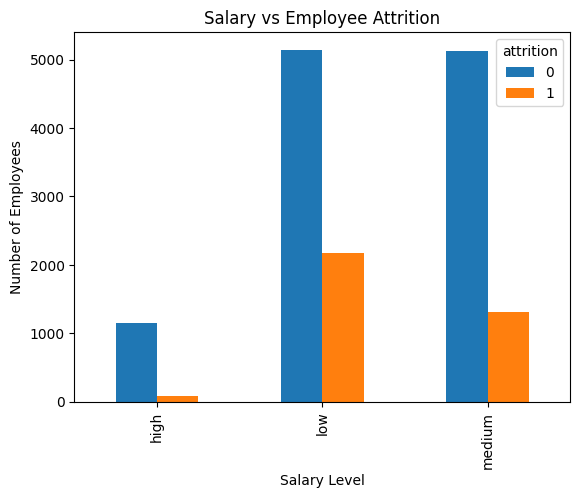

In [3]:
pd.crosstab(df.salary, df.attrition).plot(kind="bar")
plt.title("Salary vs Employee Attrition")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

Department vs Retention

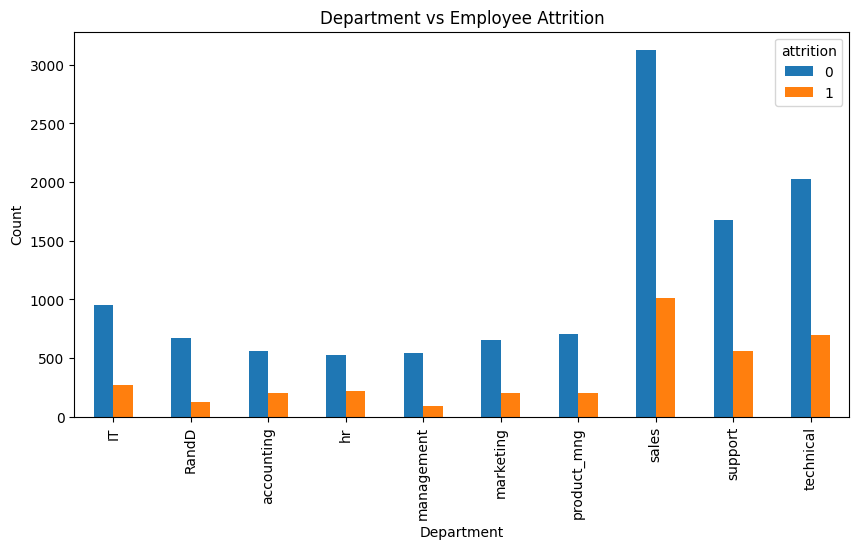

In [4]:
pd.crosstab(df.Department, df.attrition).plot(kind="bar", figsize=(10,5))
plt.title("Department vs Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

Correlation check (numeric variables)

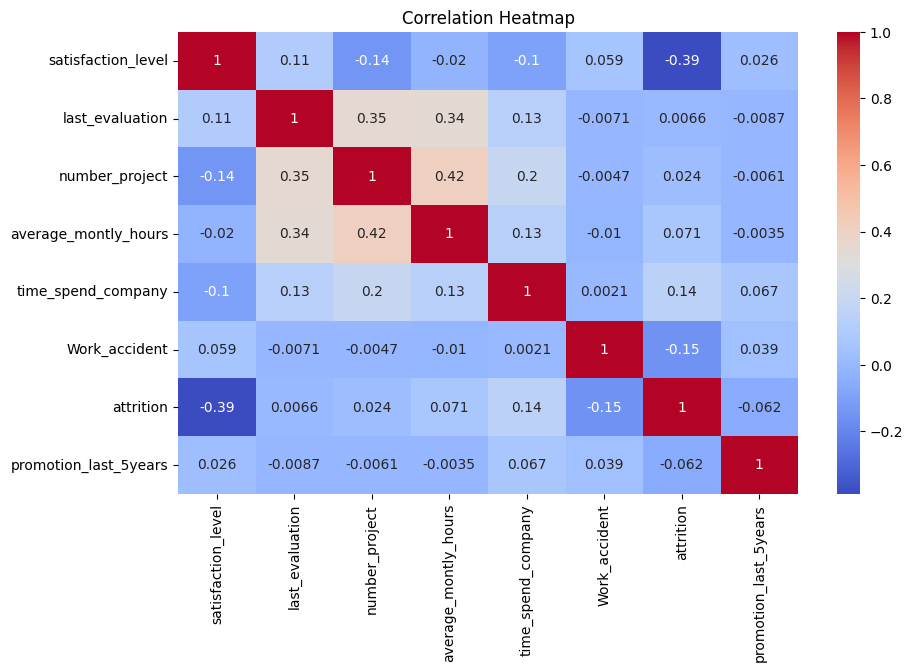

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Feature Selection

In [6]:
features = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_montly_hours",
    "time_spend_company",
    "Work_accident",
    "promotion_last_5years",
    "salary"
]
df["salary"] = df["salary"].map({"low":0, "medium":1, "high":2})

Logistic Regression Model

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df[features]
y = df["attrition"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.781

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.92      0.87      2294
           1       0.56      0.32      0.41       706

    accuracy                           0.78      3000
   macro avg       0.69      0.62      0.64      3000
weighted avg       0.76      0.78      0.76      3000

